# Unit10_PDE | 偏微分方程式 (PDE) 之求解

| 項目 | 說明 |
|------|------|
| **課程** | 電腦在化工上之應用 (ChemE 3502) |
| **單元** | Unit10：偏微分方程式 (PDE) 之求解 |
| **主要套件** | `py-pde`（有限差分法）、`scipy`（線法 MoL） |
| **次要套件** | `numpy`、`matplotlib`、`scipy.linalg` |
| **Python 版本** | 3.10 |

### 0. 環境設定

In [14]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit10_PDE'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit10'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")


✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit10
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_PDE
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit10\outputs\Unit10_PDE\figs


### 1. 載入套件

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.integrate import solve_ivp
from scipy.linalg import solve
import scipy
import pde
import warnings
warnings.filterwarnings('ignore')

# ── 版本確認 ──────────────────────────────────────────────────
print(f"numpy      版本: {np.__version__}")
print(f"scipy      版本: {scipy.__version__}")
print(f"matplotlib 版本: {mpl.__version__}")
print(f"pde (py-pde) 版本: {pde.__version__}")

# ── 隨機種子 ─────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── 繪圖樣式設定 ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "lines.linewidth": 2,
    "axes.unicode_minus": False,
})
print("✓ 套件載入完成")


numpy      版本: 1.23.5
scipy      版本: 1.15.2
matplotlib 版本: 3.10.8
pde (py-pde) 版本: 0.51.0
✓ 套件載入完成


### 2. 偏微分方程式分類

偏微分方程式依其係數的判別式 $\Delta = B^2 - 4AC$ 分為三類：

| 類型 | 條件 | 典型方程式 | 化工應用 |
|------|------|-----------|---------|
| **橢圓型** | $\Delta < 0$ | Laplace / Poisson | 穩態熱傳、穩態擴散 |
| **拋物線型** | $\Delta = 0$ | 擴散方程、熱傳方程 | 非穩態熱傳、質傳 |
| **雙曲線型** | $\Delta > 0$ | 波動方程 | 壓力波、衝擊波 |

**化工通用輸送方程式**：

$$
\frac{\partial (\rho \phi)}{\partial t} + \nabla \cdot (\rho \mathbf{v} \phi) = \nabla \cdot (\Gamma \nabla \phi) + S_\phi
$$

其中 $\phi$ 可為溫度 $T$ 、濃度 $C$ 、速度 $u$ 等守恆量。

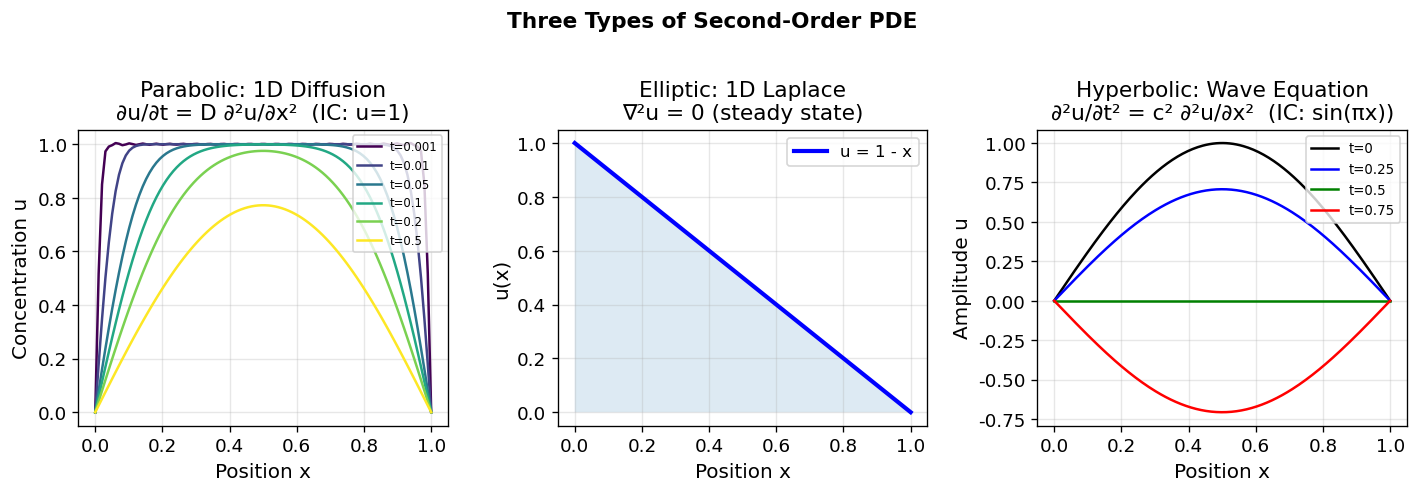

Saved: fig2_1_pde_classification.png


In [19]:
### Fig 2-1: Visualize PDE classification by discriminant

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# --- (a) Parabolic: 1D Diffusion ---
# ∂T/∂t = D ∂²T/∂x², T(0,t)=T(1,t)=0, T(x,0)=1
# Analytical: T(x,t) = Σ_{n=1,3,5,...} [4/(nπ)] sin(nπx) exp(-(nπ)²Dt)
ax = axes[0]
x = np.linspace(0, 1, 100)
colors = plt.cm.viridis(np.linspace(0, 1, 6))
D_demo = 0.1
for i, t in enumerate([0.001, 0.01, 0.05, 0.1, 0.2, 0.5]):
    n_terms = 50
    T = sum(
        (4 / (n * np.pi)) * np.sin(n * np.pi * x) * np.exp(-(n * np.pi)**2 * D_demo * t)
        for n in range(1, n_terms + 1, 2)
    )
    ax.plot(x, T, color=colors[i], lw=1.5, label=f"t={t}")
ax.set_title("Parabolic: 1D Diffusion\n∂u/∂t = D ∂²u/∂x²  (IC: u=1)")
ax.set_xlabel("Position x")
ax.set_ylabel("Concentration u")
ax.legend(fontsize=7, loc="upper right")

# --- (b) Elliptic: Laplace (1D steady state → linear) ---
ax = axes[1]
x = np.linspace(0, 1, 100)
T_steady = 1 - x  # u'' = 0 → u = 1-x with u(0)=1, u(1)=0
ax.plot(x, T_steady, "b-", lw=2.5, label="u = 1 - x")
ax.fill_between(x, T_steady, alpha=0.15)
ax.set_title("Elliptic: 1D Laplace\n∇²u = 0 (steady state)")
ax.set_xlabel("Position x")
ax.set_ylabel("u(x)")
ax.legend()

# --- (c) Hyperbolic: Wave equation snapshot ---
# u_tt = c² u_xx, u(x,0) = sin(πx), u_t(x,0) = 0
# Analytical: u(x,t) = sin(πx) cos(πct)
#           = 0.5 * [sin(π(x-ct)) + sin(π(x+ct))]
ax = axes[2]
x = np.linspace(0, 1, 200)
c = 1.0
for t, col in zip([0, 0.25, 0.5, 0.75], ["k", "b", "g", "r"]):
    u = np.sin(np.pi * x) * np.cos(np.pi * c * t)
    ax.plot(x, u, color=col, lw=1.5, label=f"t={t}")
ax.set_title("Hyperbolic: Wave Equation\n∂²u/∂t² = c² ∂²u/∂x²  (IC: sin(πx))")
ax.set_xlabel("Position x")
ax.set_ylabel("Amplitude u")
ax.legend(fontsize=8)

plt.suptitle("Three Types of Second-Order PDE", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_1_pde_classification.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_1_pde_classification.png")


### 3. Python PDE 求解工具：py-pde 快速入門

`py-pde` 是一套以**有限差分法 (FDM)** 為核心的 Python PDE 求解框架，適用於結構化網格（直角座標、圓柱座標、球座標）。

**基本工作流程（5 步驟）**：
1. 建立 **Grid** 求解域
2. 建立 **ScalarField / VectorField** 場變數並設定初始條件
3. 定義 **PDE 方程式**（`DiffusionPDE` 或 `PDE({"u": "..."})` ）
4. **設定邊界條件**（Dirichlet / Neumann / Robin）
5. 呼叫 `.solve()` 執行求解並視覺化結果

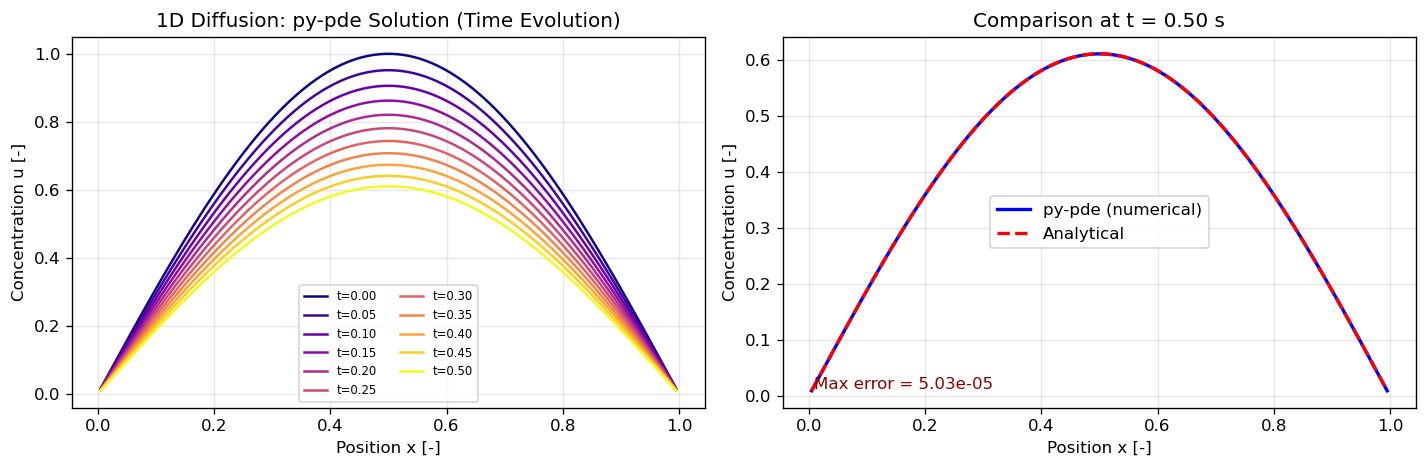

Max absolute error: 5.0331e-05


In [4]:
### py-pde Quick Demo: 1D Diffusion (Hello World)
# Problem: ∂u/∂t = D * ∂²u/∂x², 0≤x≤1, u(0)=u(1)=0, u(x,0)=sin(πx)
# Analytical solution: u(x,t) = sin(πx) * exp(-π²Dt)

D = 0.1          # diffusion coefficient
T_final = 0.5    # simulation time

# Step 1: Grid
grid = pde.CartesianGrid([[0, 1]], 100)

# Step 2: Initial condition
state = pde.ScalarField.from_expression(grid, "sin(pi * x)")

# Step 3 & 4: PDE + Dirichlet BC (u=0 at both ends)
eq = pde.DiffusionPDE(diffusivity=D, bc={"x": {"value": 0.0}})

# Step 5: Solve with storage tracker
storage = pde.MemoryStorage()
result = eq.solve(state, t_range=T_final, dt=1e-4,
                  tracker=[storage.tracker(0.05)])

# Analytical solution for comparison
x_arr = grid.axes_coords[0]
u_exact = np.sin(np.pi * x_arr) * np.exp(-np.pi**2 * D * T_final)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
times = list(storage.times)
colors_t = plt.cm.plasma(np.linspace(0, 1, len(times)))
for idx, (t, field) in enumerate(storage.items()):
    ax.plot(x_arr, field.data, color=colors_t[idx], lw=1.5, label=f"t={t:.2f}")
ax.set_xlabel("Position x [-]")
ax.set_ylabel("Concentration u [-]")
ax.set_title("1D Diffusion: py-pde Solution (Time Evolution)")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.plot(x_arr, result.data, "b-", lw=2, label="py-pde (numerical)")
ax.plot(x_arr, u_exact, "r--", lw=2, label="Analytical")
ax.set_xlabel("Position x [-]")
ax.set_ylabel("Concentration u [-]")
ax.set_title(f"Comparison at t = {T_final:.2f} s")
ax.legend()
max_err = np.max(np.abs(result.data - u_exact))
ax.text(0.05, 0.05, f"Max error = {max_err:.2e}",
        transform=ax.transAxes, fontsize=10, color="darkred")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_1_pypde_quickdemo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Max absolute error: {max_err:.4e}")

### 4. py-pde 核心物件

**四大核心物件**：

| 物件 | 用途 | 建立方式 |
|------|------|---------|
| `CartesianGrid` / `SphericalSymGrid` / `CylindricalSymGrid` | 求解域與座標系統 | `pde.CartesianGrid([[0,L]], N)` |
| `ScalarField` / `VectorField` | 場變數（溫度、濃度、速度） | `pde.ScalarField(grid, data=...)` |
| `DiffusionPDE` / `PDE` / `PDEBase` | PDE 方程式定義 | `pde.DiffusionPDE(D, bc=...)` |
| `MemoryStorage` + `.tracker()` | 收集時間序列結果 | `storage = pde.MemoryStorage()` → `storage.tracker(interval)` |

> **py-pde 0.51 注意**：舊版 `pde.StorageTracker(storage, interval=...)` 已棄用，請改用 `storage.tracker(interval)` 方法，並以 **list** 傳入 tracker 參數：`tracker=[storage.tracker(0.1)]`。

**示範：不同座標系統的 Grid 比較**

以下展示直角、球座標、圓柱座標的網格建立，並視覺化求解域結構。


In [5]:
### Section 4-1: Grid objects demonstration
# Show CartesianGrid 1D/2D, SphericalGrid, CylindricalGrid

print("=" * 55)
print("py-pde Grid Objects")
print("=" * 55)

# 1D Cartesian
g1d = pde.CartesianGrid([[0, 1]], 50)
print(f"\n[CartesianGrid 1D]  shape={g1d.shape}, dx={g1d.axes_coords[0][1]-g1d.axes_coords[0][0]:.4f}")

# 2D Cartesian
g2d = pde.CartesianGrid([[0, 2], [0, 1]], [40, 20])
print(f"[CartesianGrid 2D]  shape={g2d.shape}")

# 3D Cartesian
g3d = pde.CartesianGrid([[0, 1], [0, 1], [0, 1]], 10)
print(f"[CartesianGrid 3D]  shape={g3d.shape}")

# Spherical
g_sph = pde.SphericalSymGrid(radius=1.0, shape=100)
print(f"[SphericalSymGrid]  shape={g_sph.shape}, r_max={g_sph.axes_coords[0][-1]:.3f}")

# Cylindrical
g_cyl = pde.CylindricalSymGrid(radius=0.5, bounds_z=(0, 1.0), shape=[20, 30])
print(f"[CylindricalSymGrid] shape={g_cyl.shape}")

# --- Field operations demo ---
print("\n" + "-" * 55)
print("ScalarField Operations")
print("-" * 55)

grid = pde.CartesianGrid([[0, np.pi]], 100)
f = pde.ScalarField.from_expression(grid, "sin(x)")
print(f"  f = sin(x):  max={f.data.max():.4f}, integral={f.integral:.4f}")
lap = f.laplace(bc={"x": {"value": 0.0}})
print(f"  ∇²sin(x) = -sin(x): min={lap.data.min():.4f}  (expected ≈ -1.0 at x=π/2)")

# --- PDE definition styles ---
print("\n" + "-" * 55)
print("PDE Definition Styles")
print("-" * 55)

# Style 1: DiffusionPDE
eq1 = pde.DiffusionPDE(diffusivity=0.1)
print(f"  DiffusionPDE: {eq1}")

# Style 2: PDE with string
eq2 = pde.PDE({"C": "0.1 * laplace(C) - 0.5 * C"}, )
print(f"  PDE (string): {eq2}")

py-pde Grid Objects

[CartesianGrid 1D]  shape=(50,), dx=0.0200
[CartesianGrid 2D]  shape=(40, 20)
[CartesianGrid 3D]  shape=(10, 10, 10)
[SphericalSymGrid]  shape=(100,), r_max=0.995
[CylindricalSymGrid] shape=(20, 30)

-------------------------------------------------------
ScalarField Operations
-------------------------------------------------------
  f = sin(x):  max=0.9999, integral=2.0001
  ∇²sin(x) = -sin(x): min=-0.9998  (expected ≈ -1.0 at x=π/2)

-------------------------------------------------------
PDE Definition Styles
-------------------------------------------------------
  DiffusionPDE: <pde.pdes.diffusion.DiffusionPDE object at 0x000002822E703CD0>
  PDE (string): <pde.pdes.pde.PDE object at 0x000002822E6738E0>


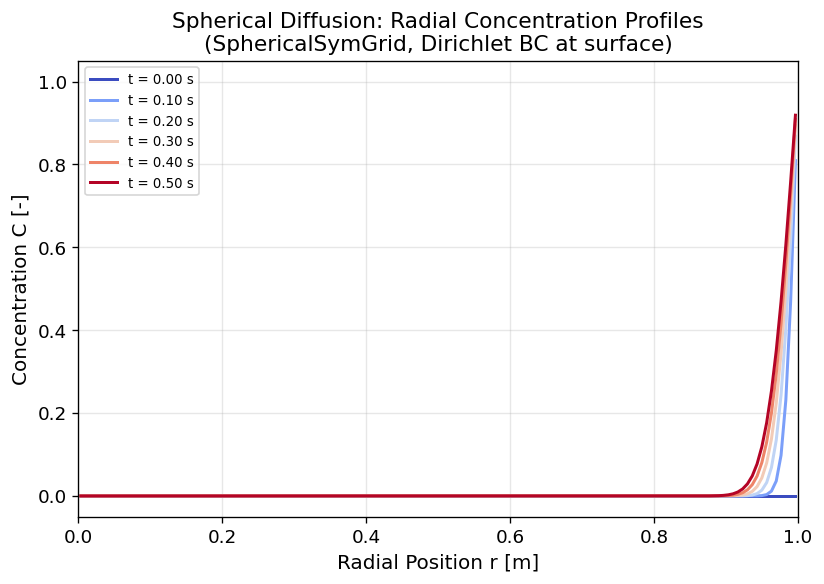

Saved: fig4_2_sphere_diffusion.png


In [17]:
### Section 4-2: Boundary Condition & SphericalGrid Demo
# Problem: Spherical diffusion, ∂C/∂t = D * ∇²C  (r-coordinate only)
# BC: C(R) = C_surface = 1.0 (Dirichlet), at r=0: automatic symmetry (∂C/∂r = 0)
# IC: C(r,0) = 0 (particle initially empty)

D_sphere  = 1e-3    # diffusion coefficient [m²/s]
R_sphere  = 1.0     # sphere radius [m]
T_final_s = 0.5     # simulation time [s]

# Spherical grid — r=0 symmetry BC handled automatically
grid_s = pde.SphericalSymGrid(radius=R_sphere, shape=150)

# Initial condition: empty sphere
C_init = pde.ScalarField(grid_s, data=0.0)

# PDE: diffusion only; outer BC = Dirichlet (surface concentration = 1)
# SphericalSymGrid has single axis 'r'; use {"value": V} to set outer BC
eq_s = pde.DiffusionPDE(
    diffusivity=D_sphere,
    bc={"value": 1.0}   # outer surface fixed at 1 (Dirichlet)
)

# Solve and collect snapshots (使用 list 傳入 tracker，符合 py-pde 0.51 規範)
storage_s = pde.MemoryStorage()
eq_s.solve(C_init, t_range=T_final_s, dt=1e-5,
           tracker=[storage_s.tracker(0.1)])

# Plot radial profiles
r = grid_s.axes_coords[0]
times_s = list(storage_s.times)
colors_s = plt.cm.coolwarm(np.linspace(0, 1, len(times_s)))

fig, ax = plt.subplots(figsize=(7, 5))
for i, (t, field) in enumerate(storage_s.items()):
    ax.plot(r, field.data, color=colors_s[i], lw=1.8,
            label=f"t = {t:.2f} s")
ax.set_xlabel("Radial Position r [m]")
ax.set_ylabel("Concentration C [-]")
ax.set_title("Spherical Diffusion: Radial Concentration Profiles\n(SphericalSymGrid, Dirichlet BC at surface)")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim([0, R_sphere])
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_2_sphere_diffusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_2_sphere_diffusion.png")


### 5. 線法 (Method of Lines, MoL)

**MoL 核心思路**：先對**空間方向**離散（有限差分），將 PDE 轉化為大型聯立 ODE 系統，再用 `scipy.integrate.solve_ivp()` 對**時間積分**。

#### 1D 擴散方程式的 MoL 推導

$$
\frac{\partial u}{\partial t} = D \frac{\partial^2 u}{\partial x^2}, \quad 0 \le x \le L
$$

空間離散（中心差分，間距 $\Delta x$ ）：

$$
\frac{d u_i}{dt} \approx D \cdot \frac{u_{i-1} - 2u_i + u_{i+1}}{\Delta x^2}, \quad i = 1, \dots, N-2
$$

轉化為矩陣形式：

$$
\frac{d\mathbf{u}}{dt} = \frac{D}{\Delta x^2} A \mathbf{u} + \mathbf{b}_{BC}
$$

其中 $A$ 為三對角線矩陣。此 ODE 系統通常是**剛性 (stiff)** 的，應選用 `Radau` 或 `BDF` 求解器。

Spatial nodes: 80, dx = 0.0123
CFL dt_max (explicit) = 7.6208e-04 s  → Using Radau (implicit, no CFL limit)


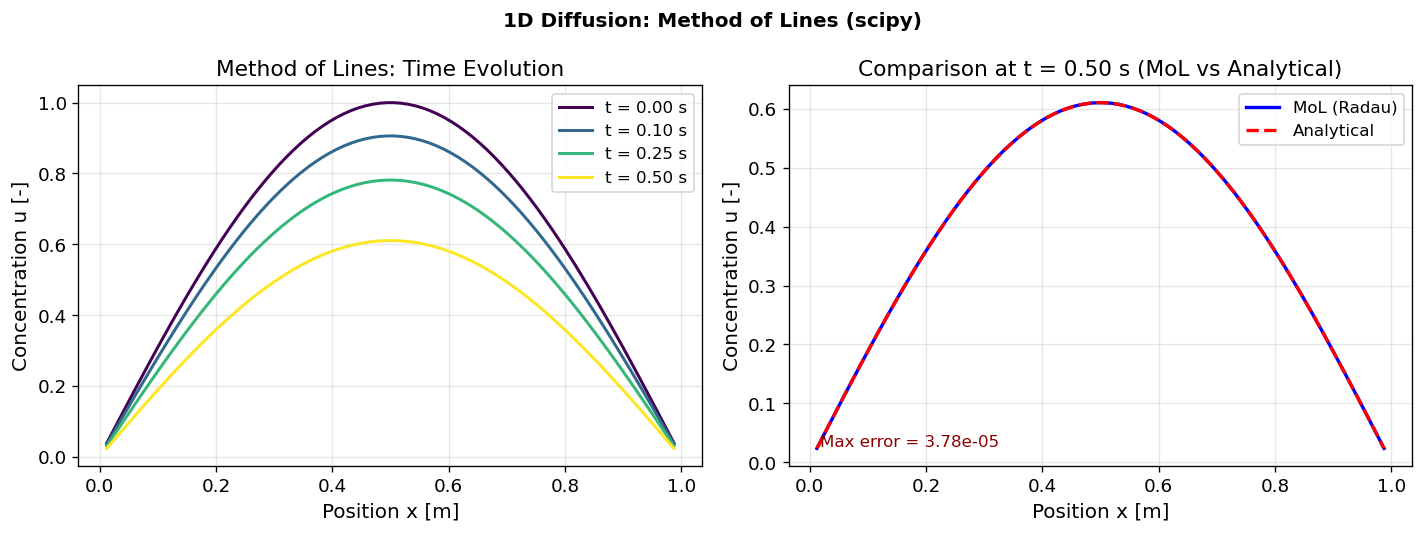

Solve status: The solver successfully reached the end of the integration interval.
Max absolute error vs analytical: 3.7758e-05


In [20]:
### Section 5: Method of Lines — 1D Diffusion with scipy
# Problem: ∂u/∂t = D ∂²u/∂x², 0≤x≤L
# IC: u(x,0) = sin(πx/L)
# BC: u(0,t) = u(L,t) = 0 (Dirichlet)
# Analytical: u(x,t) = sin(πx/L) * exp(-π²Dt/L²)

# Parameters
L_mol   = 1.0
D_mol   = 0.1
N_mol   = 80           # number of internal nodes
T_mol   = 0.5

# Spatial grid (internal nodes only)
x_int = np.linspace(0, L_mol, N_mol + 2)[1:-1]  # exclude boundaries
dx    = x_int[1] - x_int[0]

# Initial condition
u0_mol = np.sin(np.pi * x_int / L_mol)

# RHS function: ∂u/∂t = D*(u_left - 2u + u_right)/dx²
def mol_rhs(t, u):
    u_ext = np.concatenate([[0.0], u, [0.0]])    # Dirichlet BC = 0
    return D_mol * (u_ext[:-2] - 2*u_ext[1:-1] + u_ext[2:]) / dx**2

# CFL check
dt_max = 0.5 * dx**2 / D_mol
print(f"Spatial nodes: {N_mol}, dx = {dx:.4f}")
print(f"CFL dt_max (explicit) = {dt_max:.4e} s  → Using Radau (implicit, no CFL limit)")

# Solve
t_eval_mol = np.linspace(0, T_mol, 51)
sol_mol = solve_ivp(mol_rhs, [0, T_mol], u0_mol,
                    method="Radau", t_eval=t_eval_mol,
                    rtol=1e-8, atol=1e-10)

# Analytical solution
u_anal_mol = np.sin(np.pi * x_int / L_mol) * np.exp(-np.pi**2 * D_mol * T_mol / L_mol**2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
snap_idx = [0, 10, 25, 50]
cols_mol = plt.cm.viridis(np.linspace(0, 1, len(snap_idx)))
for ci, idx in enumerate(snap_idx):
    lbl = f"t = {sol_mol.t[idx]:.2f} s"
    ax.plot(x_int, sol_mol.y[:, idx], color=cols_mol[ci], lw=1.8, label=lbl)
ax.set_xlabel("Position x [m]")
ax.set_ylabel("Concentration u [-]")
ax.set_title("Method of Lines: Time Evolution")
ax.legend()

ax = axes[1]
ax.plot(x_int, sol_mol.y[:, -1], "b-", lw=2, label="MoL (Radau)")
ax.plot(x_int, u_anal_mol, "r--", lw=2, label="Analytical")
err_mol = np.max(np.abs(sol_mol.y[:, -1] - u_anal_mol))
ax.text(0.05, 0.05, f"Max error = {err_mol:.2e}", transform=ax.transAxes,
        color="darkred", fontsize=10)
ax.set_xlabel("Position x [m]")
ax.set_ylabel("Concentration u [-]")
ax.set_title(f"Comparison at t = {T_mol:.2f} s (MoL vs Analytical)")
ax.legend()

plt.suptitle("1D Diffusion: Method of Lines (scipy)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_1_mol_diffusion.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Solve status: {sol_mol.message}")
print(f"Max absolute error vs analytical: {err_mol:.4e}")


### 6. 化工 PDE 應用

本節示範兩個化工典型問題：

**6-1：2D 穩態熱傳（橢圓型 — Laplace 方程）**
矩形板穩態溫度分布，邊界條件：
- 上緣： $T = T_{\mathrm{hot}} = 100\,^\circ\mathrm{C}$ （加熱面）
- 側面與下緣： $T = 0\,^\circ\mathrm{C}$ （冷卻面）

以 `py-pde` 的拋物線方程長時間求解趨近穩態。

**6-2：1D 反應擴散（帶一階反應的 Fick's Second Law）**
單板催化劑中的反應擴散問題（Thiele 模數效應）：

$$
\frac{\partial C}{\partial t} = D \frac{\partial^2 C}{\partial x^2} - k_1 C
$$

$\Phi = L\sqrt{k_1/D}$ 為 **Thiele 模數**，描述反應與擴散速度的比值。


  0%|          | 0/5.0 [00:00<?, ?it/s]

  0%|          | 0/5.0 [00:00<?, ?it/s]

  0%|          | 0/5.0 [00:00<?, ?it/s]

  0%|          | 0/5.0 [00:00<?, ?it/s]

  0%|          | 0/5.0 [00:00<?, ?it/s]

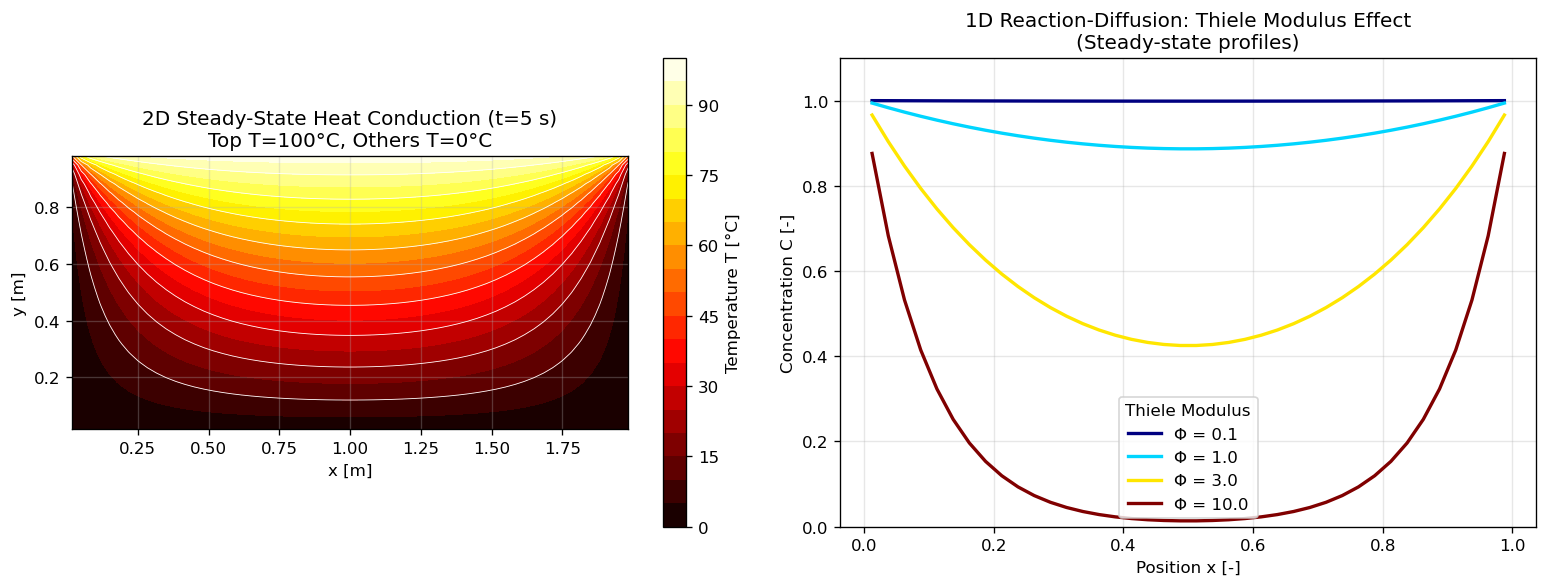

Saved: fig6_cheme_applications.png


In [13]:
### Section 6-1: 2D Steady-State Heat Conduction (Laplace Equation via py-pde)
# Geometry: 2×1 rectangular plate
# BC: top edge T=100, all other edges T=0

Lx, Ly  = 2.0, 1.0
T_hot   = 100.0
T_cold  = 0.0
nx, ny  = 60, 30
T_final_2d = 5.0   # run long enough to reach steady state

grid_2d_heat = pde.CartesianGrid([[0, Lx], [0, Ly]], [nx, ny])

# Initial condition: uniform cold plate
T_init_2d = pde.ScalarField(grid_2d_heat, data=T_cold)

# Heat equation: ∂T/∂t = α * ∇²T (α=1 without loss of generality)
# BCs: top (y=Ly) = T_hot=100, all others = T_cold=0
# py-pde 2D BC format: specify each face separately
bc_2d = {"left": {"value": T_cold}, "right": {"value": T_cold},
         "bottom": {"value": T_cold}, "top": {"value": T_hot}}

eq_2d_heat = pde.DiffusionPDE(diffusivity=1.0, bc=bc_2d)

# Solve to steady state
T_ss = eq_2d_heat.solve(T_init_2d, t_range=T_final_2d, dt=1e-4)

# Plot steady-state temperature field
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_h = grid_2d_heat.axes_coords[0]
y_h = grid_2d_heat.axes_coords[1]
X_h, Y_h = np.meshgrid(x_h, y_h, indexing="ij")

ax = axes[0]
cf = ax.contourf(X_h, Y_h, T_ss.data, levels=20, cmap="hot")
plt.colorbar(cf, ax=ax, label="Temperature T [°C]")
ax.contour(X_h, Y_h, T_ss.data, levels=10, colors="w", linewidths=0.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"2D Steady-State Heat Conduction (t={T_final_2d:.0f} s)\nTop T=100°C, Others T=0°C")
ax.set_aspect("equal")

### Section 6-2: 1D Reaction-Diffusion (Thiele Modulus Effect)
# ∂C/∂t = D*∂²C/∂x² - k1*C,  0≤x≤1
# BC: C(0)=C(1)=1 (surface), IC: C(x,0)=0

D_rd   = 1.0
T_rd   = 5.0
thiele_list = [0.1, 1.0, 3.0, 10.0]

ax = axes[1]
colors_th = plt.cm.jet(np.linspace(0, 1, len(thiele_list)))

for ci, Phi in enumerate(thiele_list):
    k1 = (Phi**2) * D_rd  # k1 = Phi^2 * D / L^2 (L=1)
    # N=40 → dx=0.025, CFL dt_max = 0.5*0.025²/D = 3.1e-4 > dt=1e-4 → stable
    grid_rd = pde.CartesianGrid([[0, 1]], 40)
    C_init_rd = pde.ScalarField(grid_rd, data=0.0)
    eq_rd = pde.PDE({"C": f"{D_rd} * laplace(C) - {k1:.6f} * C"},
                    bc={"x": {"value": 1.0}})
    C_ss_rd = eq_rd.solve(C_init_rd, t_range=T_rd, dt=1e-4)
    ax.plot(grid_rd.axes_coords[0], C_ss_rd.data,
            color=colors_th[ci], lw=2.0, label=f"Φ = {Phi}")

ax.set_xlabel("Position x [-]")
ax.set_ylabel("Concentration C [-]")
ax.set_title("1D Reaction-Diffusion: Thiele Modulus Effect\n(Steady-state profiles)")
ax.legend(title="Thiele Modulus")
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_cheme_applications.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig6_cheme_applications.png")


### 7. 程式設計最佳實踐與工具選擇總結

#### 工具選擇決策樹

```
        化工 PDE 問題
               │
    ┌──────────┴──────────┐
    │ 幾何是否為標準形狀？   │
    │ (矩形/圓柱/球體)      │
    └──────────────────────┘
          │ 是           │ 否
          ▼              ▼
      py-pde          COMSOL / FEniCS
    (本課程範圍)      (進階課程)
          │
    ┌─────┴──────┐
    │需要精細控制？│
    └────────────┘
     │ 是    │ 否
     ▼       ▼
  scipy     py-pde
  MoL      (直接用)
```

#### 數值穩定性準則

| 項目 | 說明 |
|------|------|
| **CFL 條件** (顯式) | $dt \le \frac{\Delta x^2}{2D}$ |
| **建議求解器** | `Radau` 或 `BDF`（隱式，無 CFL 限制） |
| **網格收斂性** | 加密網格後結果差異 < 5% |
| **能量/質量守恆** | 對保守系統驗證整體守恆量 |

  0%|          | 0/0.5 [00:00<?, ?it/s]

  N=  20: max error = 1.2420e-03


  0%|          | 0/0.5 [00:00<?, ?it/s]

  N=  40: max error = 3.0992e-04


  0%|          | 0/0.5 [00:00<?, ?it/s]

  N=  80: max error = 7.7444e-05


  0%|          | 0/0.5 [00:00<?, ?it/s]

  N= 160: max error = 1.9359e-05


  0%|          | 0/0.5 [00:00<?, ?it/s]

  N= 320: max error = 4.8396e-06

Convergence order (error ratio ≈ 4 = 2² for 2nd-order scheme):
  N=20→40: ratio = 4.01  (order ≈ 2.00)
  N=40→80: ratio = 4.00  (order ≈ 2.00)
  N=80→160: ratio = 4.00  (order ≈ 2.00)
  N=160→320: ratio = 4.00  (order ≈ 2.00)


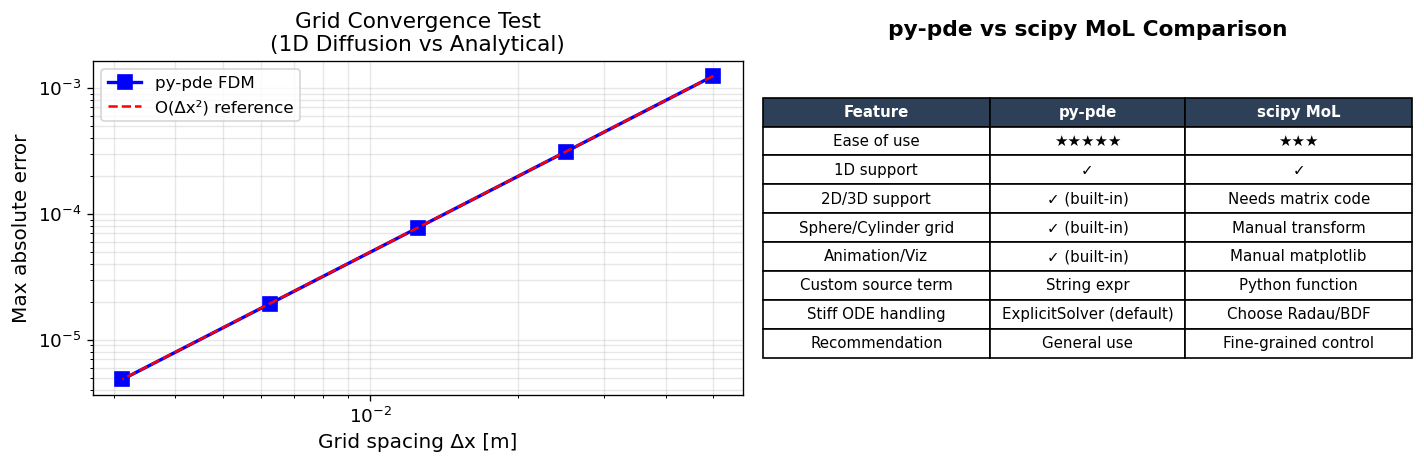


Grid convergence test complete.


In [18]:
### Section 7: Grid Convergence Test & py-pde vs scipy MoL comparison
# Verify mesh independence for 1D diffusion (analytical solution known)

D_conv = 0.1
T_conv = 0.5
N_list = [20, 40, 80, 160, 320]
errors = []

for N in N_list:
    grid_c = pde.CartesianGrid([[0, 1]], N)
    state_c = pde.ScalarField.from_expression(grid_c, "sin(pi * x)")
    eq_c = pde.DiffusionPDE(diffusivity=D_conv, bc={"x": {"value": 0.0}})
    result_c = eq_c.solve(state_c, t_range=T_conv, dt=0.5 * (1/N)**2 / D_conv)

    x_c = grid_c.axes_coords[0]
    u_exact_c = np.sin(np.pi * x_c) * np.exp(-np.pi**2 * D_conv * T_conv)
    err = np.max(np.abs(result_c.data - u_exact_c))
    errors.append(err)
    print(f"  N={N:4d}: max error = {err:.4e}")

# Compute convergence order
print("\nConvergence order (error ratio ≈ 4 = 2² for 2nd-order scheme):")
for i in range(1, len(errors)):
    ratio = errors[i-1] / errors[i]
    print(f"  N={N_list[i-1]}→{N_list[i]}: ratio = {ratio:.2f}  (order ≈ {np.log2(ratio):.2f})")

# Plot convergence
dx_list = [1.0 / N for N in N_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.loglog(dx_list, errors, "bs-", lw=2, ms=8, label="py-pde FDM")
# Reference 2nd-order line
ref_x = np.array([dx_list[0], dx_list[-1]])
ref_y = errors[0] * (ref_x / dx_list[0])**2
ax.loglog(ref_x, ref_y, "r--", lw=1.5, label="O(Δx²) reference")
ax.set_xlabel("Grid spacing Δx [m]")
ax.set_ylabel("Max absolute error")
ax.set_title("Grid Convergence Test\n(1D Diffusion vs Analytical)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# py-pde vs scipy MoL summary table
ax = axes[1]
ax.axis("off")
table_data = [
    ["Feature", "py-pde", "scipy MoL"],
    ["Ease of use", "★★★★★", "★★★"],
    ["1D support", "✓", "✓"],
    ["2D/3D support", "✓ (built-in)", "Needs matrix code"],
    ["Sphere/Cylinder grid", "✓ (built-in)", "Manual transform"],
    ["Animation/Viz", "✓ (built-in)", "Manual matplotlib"],
    ["Custom source term", "String expr", "Python function"],
    ["Stiff ODE handling", "ExplicitSolver (default)", "Choose Radau/BDF"],
    ["Recommendation", "General use", "Fine-grained control"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc="center", loc="center",
               colWidths=[0.35, 0.3, 0.35])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for j in range(3):
    tbl[0, j].set_facecolor("#2E4057")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
ax.set_title("py-pde vs scipy MoL Comparison", fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_convergence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGrid convergence test complete.")


---

## 單元總結

本單元介紹了化工程序中 PDE 的求解方法，重點摘要如下：

| 主題 | 核心要點 |
|------|---------|
| **PDE 分類** | 橢圓型（穩態）、拋物線型（非穩態）、雙曲線型（波動） |
| **邊界條件** | Dirichlet（值）、Neumann（通量）、Robin（對流換熱） |
| **py-pde** | 結構化網格（直角/圓柱/球形），`DiffusionPDE`/`PDE`/`PDEBase`，內建動畫 |
| **scipy MoL** | 空間差分化 → 大型 ODE → `solve_ivp(Radau)`，適合剛性問題 |
| **工具限制** | 複雜幾何/多物理/湍流 → COMSOL Multiphysics / ANSYS Fluent |
| **驗證方法** | 解析解對照、網格收斂性、守恆量檢查 |

> **下一步**：Unit10_Example_01 ~ 06 及 N-S / Fick / Fourier 專題範例，將以本單元工具分別解決各類化工 PDE 問題。

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit10 偏微分方程式 (PDE) 之求解
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-02-22

**課程授權 [CC BY-NC-SA 4.0]**  
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。